In [1]:
# Bas2

In [2]:
import numpy as np
import scipy.stats as st
import seaborn as sns
import scipy.stats as st
import matplotlib.pyplot as plt

In [3]:
# Exercise 1

'''Add the CSV-file containing the grades of students path on your computer to open this file. Bas '''
file_path = input("Enter the path to the CSV file: ")

'''Make an empty list named records. Bas'''
records = []

'''Open the file in reader mode and automatically close it when done. Bas'''
with open(file_path, 'r') as file:
    '''Make sure you read the columns names right.'''
    csv_reader = csv.DictReader(file)
    '''Adding for each row in the csv-file... Bas'''
    for row in csv_reader:
        '''Ádd the dictionary item (grade) to the empty list records. Bas'''
        records.append(row)

'''Calculate the total grades using the sum-function. Bas'''
total = sum(float(record['Grade']) for record in records)

'''Calculate the average grade by dividing the total grad by the number of rows (number of students). Bas'''
average = total / len(records)


FileNotFoundError: [Errno 2] No such file or directory: ''

In [ ]:
import math
import numpy as np

# Complex getal en beginwaarden
x,y = -0.7,0.6

c = complex(x,y)
z = 0+0j
max_stappen = 100
divergentie_index = max_stappen

# Herhaal de formule z = z^2+c
for n in range(max_stappen):
    z = z**2+c
# Checken of de waarde groter is dan 2
    if np.abs(z)>2:
        divergentie_index = n
        break

print(divergentie_index,n)


5 5


None 40000


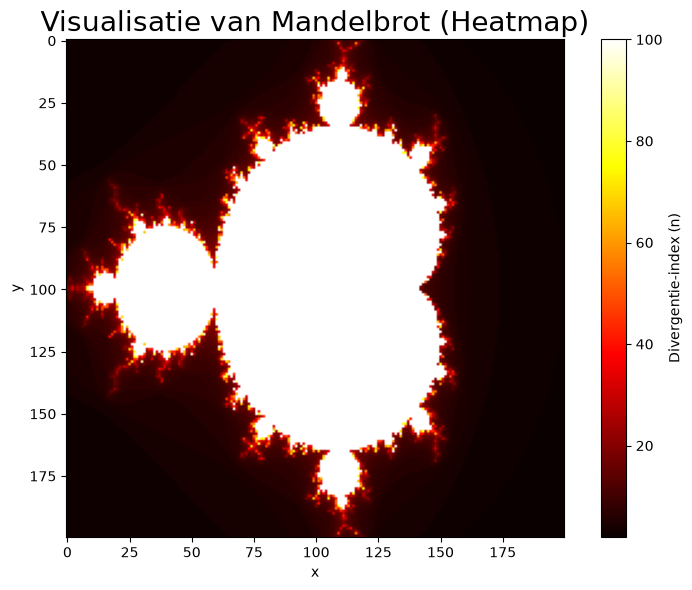

In [ ]:
# Exercise 2 goed
from scipy.ndimage import rotate
import matplotlib.pyplot as plt

# Lege lijsten voor x en y aanmaken en dan arrays van x en y genereren
x =[]
y =[]

def generate_x_en_y(width): # Genereert de benodige x en y
    x.extend(np.linspace(-1.5, 1,width)) # Maakt alle benodige x   
    y.extend(np.linspace(-1, 1, width)) # Maakt alle benodige y

generate_x_en_y(200)

# c-waarden berekenen
c = [] # maakt een lijst aan voor alle c's die we nodig hebben
def complex(x,y): # Definieert de complex functie   
    for x_value in x: # Pakt alle x van de x lijst
        for y_value in y: # Pakt alle y van de y lijst
            c.append(x_value + y_value * 1j) # Rekent de x + y*i uit en voegt deze toe aan een list 

print(complex(x,y),len(c))

# Divergentie-index n berekenen voor elke c in de ljist 
n_waarden = []
max_stappen = 100 # meer stappen geeft meer detail

for c_waarde in c:
    an_oud = 0  # Op 0 beginnen voor elk nieuw complex getal
    n = 0
    # oude waarde checken
    while abs(an_oud) <= 2 and n < max_stappen:
        an_nieuw = an_oud**2 + c_waarde  # Nieuwe waarde berekenen
        an_oud = an_nieuw                # Update an_oud voor volgende stap
        n += 1 # n = n+1
        
    n_waarden.append(n)
# figuur tekenen met functie draw_mandel
def draw_mandel_heatmap(width):
    grid = np.array(n_waarden).reshape(width,width)
    grid_gedraaid = rotate(grid, angle=90, reshape=False) # figuur met 90 graden naar links draaien
    plt.figure(figsize =(8,6))
    plt.title('Visualisatie van Mandelbrot (Heatmap)',fontsize=20)
    plt.imshow(grid_gedraaid,cmap='hot')    
    plt.colorbar(label='Divergentie-index (n)')
    plt.xlabel('x')
    plt.ylabel('y')

    plt.tight_layout()
    plt.show()

draw_mandel_heatmap(200)


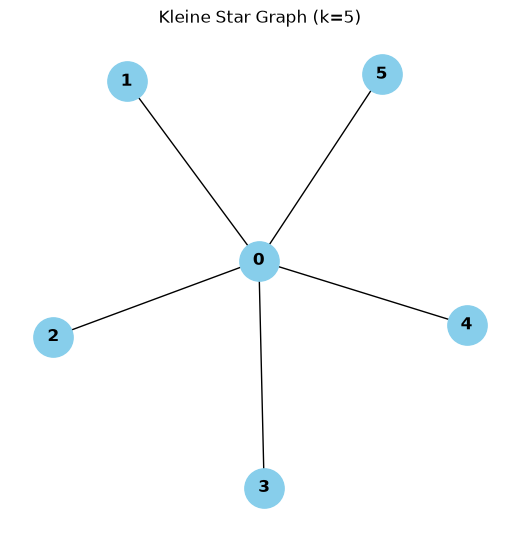

In [27]:
# Exercise 3.1
import random
import matplotlib.pyplot as plt
import networkx as nx

# Kleinn Starnetwerk maken om te oefenenen
def maak_star_graph(k: int):
    """ Klein Startnetwerk aanmaken met centrum 0 om te oefenen. Bas"""
    # centrum aanmaken
    G = nx.Graph()
    centrum = 0
    G.add_node(centrum)

    # k knopen toevoegen + verbinden met centrum
    for i in range(1, k + 1):
        G.add_node(i)
        G.add_edge(centrum, i)
    return G

# Dit kleine netwerk visualiseren

# Netwerk aanmaken
G_klein = nx.star_graph(5)

# Netwerk visualiseren
plt.figure(figsize=(5, 5))
nx.draw(G_klein,with_labels=True,node_color="skyblue",node_size=800,font_weight="bold",
)
plt.title("Kleine Star Graph (k=5)")
plt.grid(True)
plt.show()



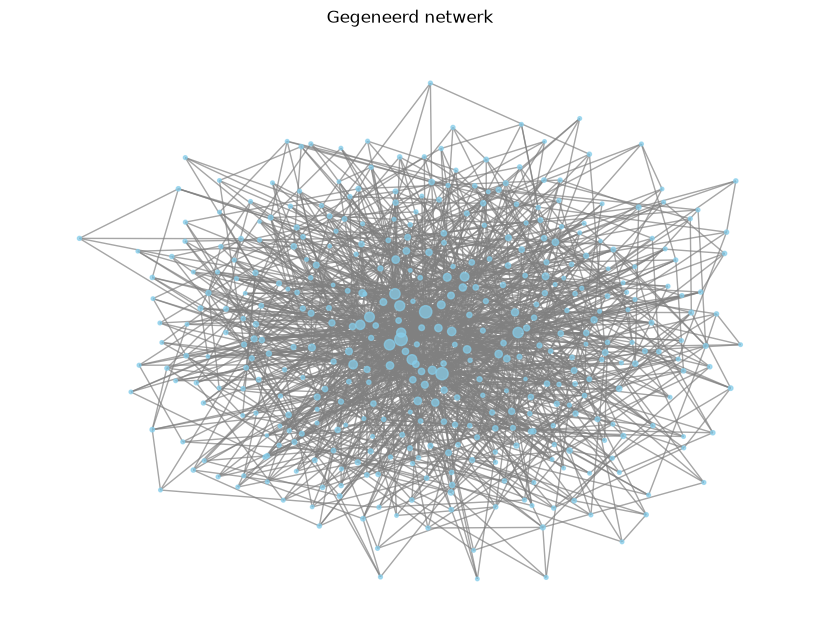

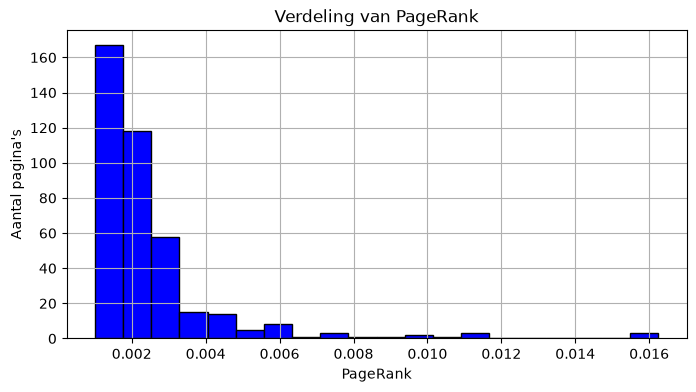

In [35]:
# Barabasi-Albert Netwerk maken (op basis van parameters N,k en M)
def genereer_barabasi_albert(N: int, k: int, M: int):
    """Barabsi-Albert Netwerk genereren met parameters N,k en M. Bas."""
    
    G = maak_star_graph(k)

    # Voeg stapsgewijs nieuwe pagina's toe
    for nieuwe_pagina in range(k + 1, N):
        bestaande = list(G.nodes())
        graden = [G.degree(n) for n in bestaande]  # Di

        # Kies M unieke knopen om mee te verbinden
        doelen = set()
        while len(doelen) < M:
            doel = random.choices(bestaande, weights=graden)[0] # Kiezen op basis van de formule van Pi
            doelen.add(doel)

        # Voeg de nieuwe verbindingen toe aan de grafiek
        for doel in doelen:
            G.add_edge(nieuwe_pagina, doel)
    return G


# PageRank Simuleren
def simuleer_pagerank(G: nx.Graph, alpha: float = 0.85, T: int = 100000):
    """Simuleert een surfer op het netwerk om de PageRank te schatten. Bas """
    bezoeken = {n: 0 for n in G.nodes()}
    huidige = random.choice(list(G.nodes()))

    # Voer T stappen uit in de simulatie
    for _ in range(T):
        bezoeken[huidige] += 1
        buren = list(G.neighbors(huidige))

        # Met kans alpha volgen we een link, anders springen we willekeurig
        if random.random() < alpha and buren:
            huidige = random.choice(buren)
        else:
            huidige = random.choice(list(G.nodes()))

    # Bereken de relatieve fractie bezoeken per knoop
    return {n: count / T for n, count in bezoeken.items()} # formuel van Pi van het word-document implementeren


# Visualisatie maken
def visualiseer_resultaten(G: nx.Graph, pagerank: Dict[int, float]):
    """Simpele visualisatie van het netwerk en de PageRank verdeling. Bas"""
    # Figuur aanmaken
    plt.figure(figsize=(8, 6))
    
    # Netwerk visualiseren
    maten = [pagerank[node] * 5000 for node in G.nodes()]
    
    nx.draw(G, node_size=maten, node_color="skyblue", edge_color="gray", alpha=0.7)
    plt.title("Gegeneerd netwerk")
    plt.grid(True)
    plt.show()

    # Histogram maken
    plt.figure(figsize=(8, 4))
    plt.hist(pagerank.values(), bins=20, color="blue",edgecolor='k')
    plt.title("Verdeling van PageRank")
    plt.xlabel("PageRank")
    plt.ylabel("Aantal pagina's")
    plt.grid(True)
    plt.show()

# Parameters volgens de opdracht (de waarden van de parameters kan ik aanpassen dus de code is generiek)
k_start = 5  
M_links = 4 
N_totaal = 400  
T_stappen = 100000  

# Netwerk genereren, PageRank bepalen via simulatie en visualisaties tonen
netwerk = genereer_barabasi_albert(N=N_totaal, k=k_start, M=M_links)
pagerank_scores = simuleer_pagerank(netwerk, alpha=0.85, T=T_stappen)
visualiseer_resultaten(netwerk, pagerank_scores)


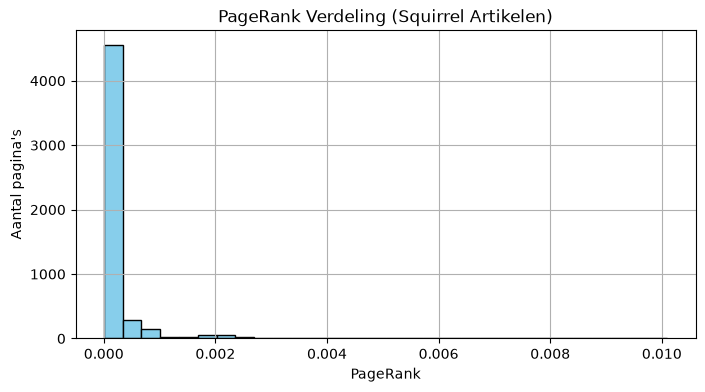

In [ ]:
# Exercise 3.2
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import random

# CSV inlezen
df = pd.read_csv('squirrel_edges.csv')
G_squirrel = nx.from_pandas_edgelist(df, source='id1', target='id2', create_using=nx.DiGraph())

# PageRank simulatie (werkt voor gericht en ongericht)
def simuleer_pagerank_gericht(G, alpha=0.85, T=100000):
    """Gerichte Pagerank simuleren. Bas"""
    bezoeken = {n: 0 for n in G.nodes()}
    huidige = random.choice(list(G.nodes()))

    # Voor elk stap die die de gesimuleerde surfer doorloopt
    for _ in range(T):
        bezoeken[huidige] += 1 # bij elke stap bezoekt de surfer 1 pagina en verhoogt bij de teller va de pagina met +1
        
        # Bij een gericht netwerk kijken we naar uitgaand buren (successors)
        if G.is_directed():
            buren = list(G.successors(huidige))
        else:
            buren = list(G.neighbors(huidige))

        # Als er uitgaande links zijn én we kiezen voor alpha: volg een link
        if random.random() < alpha and buren:
            huidige = random.choice(buren)
        else:
            # Anders (of als de pagina een 'doodlopend spoor' is): spring willekeurig
            huidige = random.choice(list(G.nodes()))

    return {n: count / T for n, count in bezoeken.items()} # formule Pi implementeren

# Pagerank van de simulatie en officiële Pagerank + visualisatie
pagerank_sim = simuleer_pagerank_gericht(G_squirrel)
pagerank_nx = nx.pagerank(G_squirrel, alpha=0.85)

def hist_pagerank(pagerank_sim):
    """Histogram maken van de PageRank-simulaties. Bas"""
    plt.figure(figsize=(8, 4))
    plt.hist(pagerank_sim.values(), bins=30, color='skyblue', edgecolor='black')
    plt.title("PageRank Verdeling (Squirrel Artikelen)")
    plt.xlabel("PageRank") 
    plt.ylabel("Aantal pagina's")
    plt.grid(True)
    plt.show()

hist_pagerank(pagerank_sim=pagerank_sim) 
